In [2]:
import os, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Signal research, persistence & basis lead

Need to understand if there is any signal here at all before we start figuring out models to fit.

## Persistence check
Let's start with an autocorrelation check, does funding rate have any correlation with previouos instances of itself? If autocorrelation is near 0 across symbols, then funding is not forecasable from it's own history, then the modelling funding will not work and we will have to consider basis instead.

In [3]:
DATA = os.path.expanduser("~/quant-platform/data/binance_historical")

SYMBOLS = ["BTCUSDT", "ETHUSDT", "SOLUSDT", "BNBUSDT", "XRPUSDT",
           "DOGEUSDT", "ADAUSDT", "LINKUSDT", "AVAXUSDT", "LTCUSDT"]

FUNDING_COLS = ["symbol", "kind", "ts_ms", "interval_hours", "rate"]

def load_funding(symbol: str) -> pd.Series:
    """Concat monthly funding CSVs for one symbol into a rate series indexed by settlement time."""
    files = sorted(glob.glob(os.path.join(DATA, symbol, "futures", "funding", f"{symbol}-fundingRate-*.csv")))
    if not files:
        raise FileNotFoundError(f"no funding CSVs for {symbol}")
    df = pd.concat((pd.read_csv(f, header=None, names=FUNDING_COLS) for f in files), ignore_index=True)
    df["ts"] = pd.to_datetime(df["ts_ms"], unit="ms")
    df = df.sort_values("ts").drop_duplicates("ts")
    return df.set_index("ts")["rate"]

In [4]:
funding = {sym: load_funding(sym) for sym in SYMBOLS}

for sym, s in funding.items():
    print(f"{sym:9s}  n={len(s):5d}  first={s.index[0].date()}  last={s.index[-1].date()}  "
          f"mean={s.mean():+.5f}  std={s.std():.5f}")

BTCUSDT    n= 3288  first=2022-01-01  last=2024-12-31  mean=+0.00007  std=0.00010
ETHUSDT    n= 3288  first=2022-01-01  last=2024-12-31  mean=+0.00007  std=0.00014
SOLUSDT    n= 3363  first=2022-01-01  last=2024-12-31  mean=-0.00007  std=0.00117
BNBUSDT    n= 3288  first=2022-01-01  last=2024-12-31  mean=-0.00007  std=0.00026
XRPUSDT    n= 3288  first=2022-01-01  last=2024-12-31  mean=+0.00007  std=0.00014
DOGEUSDT   n= 3288  first=2022-01-01  last=2024-12-31  mean=+0.00008  std=0.00013
ADAUSDT    n= 3288  first=2022-01-01  last=2024-12-31  mean=+0.00006  std=0.00014
LINKUSDT   n= 3288  first=2022-01-01  last=2024-12-31  mean=+0.00009  std=0.00011
AVAXUSDT   n= 3288  first=2022-01-01  last=2024-12-31  mean=+0.00004  std=0.00020
LTCUSDT    n= 3288  first=2022-01-01  last=2024-12-31  mean=+0.00008  std=0.00012


SOLUSDT has some missing entries for some reason, going to ignore it now, might have something to do with the funding period changing. Means and STD look sane and directional. 

## Autocorrelation, lag 1 and lag N

Lag is a count of settlements (each print is one 8h interval), not wall clock time, so it's robust to any interval irregularities in the raw data. N picked at roughly 1 day / 1 week / 1 month of 8h prints (3 / 21 / 90). 95% significance band under the null of no autocorrelation is ±1.96/sqrt(n).

In [5]:
LAGS = [1, 3, 21, 90]

rows = []
for sym, s in funding.items():
    n = len(s)
    band = 1.96 / np.sqrt(n)
    row = {"symbol": sym, "n": n, "band_95pct": band}
    for lag in LAGS:
        row[f"acf_lag{lag}"] = s.autocorr(lag=lag)
    rows.append(row)

acf_table = pd.DataFrame(rows).set_index("symbol")
acf_table.round(4)


,n,band_95pct,acf_lag1,acf_lag3,acf_lag21,acf_lag90
symbol,,,,,,
BTCUSDT,3288,0.0342,0.7793,0.6484,0.4444,0.1950
ETHUSDT,3288,0.0342,0.7973,0.5893,0.3569,0.1534
SOLUSDT,3363,0.0338,0.8699,0.7484,0.1587,0.0561
BNBUSDT,3288,0.0342,0.7618,0.6427,0.1622,-0.0370
XRPUSDT,3288,0.0342,0.7065,0.6505,0.4882,0.2602
DOGEUSDT,3288,0.0342,0.7332,0.6359,0.3996,0.1932
ADAUSDT,3288,0.0342,0.7399,0.6376,0.4081,0.2234
LINKUSDT,3288,0.0342,0.8016,0.6977,0.3796,0.1564
AVAXUSDT,3288,0.0342,0.7229,0.5787,0.4282,0.1860


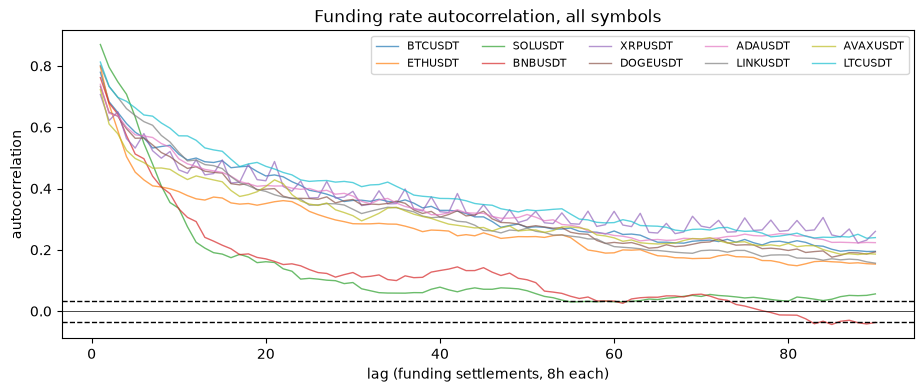

In [6]:
MAX_LAG = 90

fig, ax = plt.subplots(figsize=(11, 4))
for sym, s in funding.items():
    acf = [s.autocorr(lag=l) for l in range(1, MAX_LAG + 1)]
    ax.plot(range(1, MAX_LAG + 1), acf, label=sym, alpha=0.7, lw=1)

band = 1.96 / np.sqrt(min(len(s) for s in funding.values()))
ax.axhline(band, color="k", ls="--", lw=1)
ax.axhline(-band, color="k", ls="--", lw=1)
ax.axhline(0, color="k", lw=0.5)
ax.set_xlabel("lag (funding settlements, 8h each)")
ax.set_ylabel("autocorrelation")
ax.set_title("Funding rate autocorrelation, all symbols")
ax.legend(ncol=5, fontsize=8)
plt.show()


### Read

Strongly persistent. Every symbol, every lag, far outside the significance band.

ACF decays smoothly, no kink. No fast, discrete regime flips inside the ~1 month window tested.

But lag 90 values (0.15-0.26) are far above what a stationary AR(1) at lag-1≈0.78 predicts (~0). Decay this slow implies a drifting mean, not a fixed one. Consistent with H1's known regime split (2022-23 vs 2024): local mean-reversion around a level that itself moves.

EWMA over fixed lookback or lag-1 only. Plain EWMA partly tracks the drift but doesn't separate short-window from long-window level. Worth testing both trailing windows, or a regime feature, against it.

SOLUSDT and BNBUSDT decay much faster than the rest, hitting the noise floor by ~lag 60. SOL's faster apparent decay is at least partly an artifact of the missing entries, so "lag 90" isn't the same wall-clock horizon for SOL as for the others. BNB's fast decay looks real, not an interval artifact.

Funding has real memory, so both "model funding directly" and basis are worth pursuing

KaTeX form:

$$
\text{funding} = \overline{P} + \operatorname{clamp}\left(i - \overline{P},\ -0.05\%,\ +0.05\%\right)
$$

where $\overline{P}$ is `avg_premium_index` and $i$ is the constant `interest_rate`.

If you want it spelled out with the premium's own definition inline:

$$
\overline{P} = \operatorname{TWAP}_{[t-8h,\ t]}\left(\frac{\text{mark}_s - \text{index}_s}{\text{index}_s}\right)
$$

Jupyter markdown cells render KaTeX/MathJax natively (`$...$` inline, `$$...$$` block), so this drops straight into a notebook markdown cell as-is if you want it there instead of prose.

## Basis leads funding (BTC, mechanism check)

Binance's funding formula: 
$$
\text{funding} = \overline{P} + \operatorname{clamp}\left(i - \overline{P},\ -0.05\%,\ +0.05\%\right)
$$
, where `avg_premium_index` is a time weighted average of `(futures_mark - index_price) / index_price` sampled through the 8h interval. Funding is derived from basis with a lag, not independent of it.

`index_price` is a composite across multiple external spot exchanges, which we don't have on disk. Using Binance's own spot close as a stand in for it.

Interval boundaries come from `funding["BTCUSDT"]`'s own settlement timestamps, not an assumed fixed 8h grid.

In [7]:
KLINE_COLS = ["symbol", "kind", "open_time_ms", "open", "high", "low", "close", "volume",
              "close_time_ms", "quote_volume", "trades", "taker_buy_base", "taker_buy_quote", "ignore"]


def load_close_series(symbol: str, subpath: str) -> pd.Series:
    """Concat daily 1m kline/markprice CSVs under data/<symbol>/<subpath>/ into a close-price series."""
    files = sorted(glob.glob(os.path.join(DATA, symbol, subpath, f"{symbol}-1m-*.csv")))
    if not files:
        raise FileNotFoundError(f"no kline CSVs under {symbol}/{subpath}")
    parts = []
    for f in files:
        df = pd.read_csv(f, header=None, names=KLINE_COLS, usecols=["open_time_ms", "close"])
        parts.append(df)
    df = pd.concat(parts, ignore_index=True)
    df["ts"] = pd.to_datetime(df["open_time_ms"], unit="ms")
    df = df.sort_values("ts").drop_duplicates("ts")
    return df.set_index("ts")["close"]

In [ ]:
# Loads full 3y of 1-min data for BTC, both legs -- takes a minute or two.
mark_btc = load_close_series("BTCUSDT", "futures/markprice")
spot_btc = load_close_series("BTCUSDT", "spot/klines")

px = pd.concat([mark_btc.rename("mark"), spot_btc.rename("spot")], axis=1, join="inner")
px["basis"] = (px["mark"] - px["spot"]) / px["spot"]
print(f"{len(px)} aligned minutes, {px.index[0]} to {px.index[-1]}")
px.head()

1577944 aligned minutes, 2022-01-01 00:00:00 to 2024-12-31 23:59:00


,mark,spot,basis
ts,,,
2022-01-01 00:00:00,46250.639334,46250.00,0.000014
2022-01-01 00:01:00,46306.322785,46312.76,-0.000139
2022-01-01 00:02:00,46363.619298,46368.73,-0.000110
2022-01-01 00:03:00,46333.582879,46331.08,0.000054
2022-01-01 00:04:00,46326.451743,46321.34,0.000110


In [ ]:
# Bucket per-minute basis into the same settlement intervals as the funding series, then average
# This approximates the time-weighted avg_premium_index Binance computes per interval.
funding_btc = funding["BTCUSDT"]

bucket = pd.cut(px.index, bins=funding_btc.index, right=True, labels=funding_btc.index[1:])
basis_avg = px["basis"].groupby(bucket, observed=True).mean()
basis_avg.index = pd.to_datetime(basis_avg.index)
basis_avg.name = "basis_avg"

print(f"{len(basis_avg)} intervals bucketed (of {len(funding_btc) - 1} possible)")
basis_avg.describe()


3287 intervals bucketed (of 3287 possible)


count    3287.000000
mean       -0.000207
std         0.000379
min        -0.001746
25%        -0.000434
50%        -0.000374
75%        -0.000162
max         0.001364
Name: basis_avg, dtype: float64

### Contemporaneous check

Quick check to see if our estimation of the funding rate is at least close to the funding the rate. If not we will have to get more data.

MAE  = 0.000024
R^2  = 0.8132  (vs formula, not a linear fit)


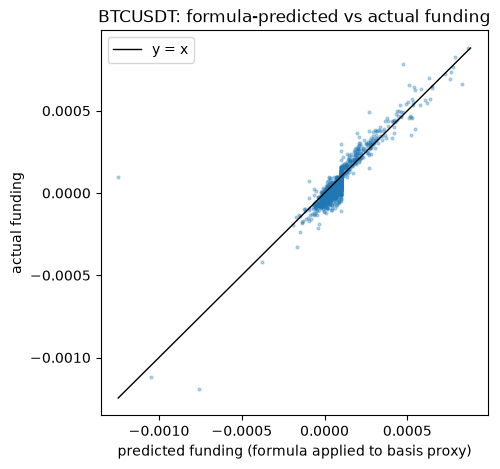

In [12]:
aligned = pd.concat([basis_avg, funding_btc], axis=1, join="inner").dropna()
aligned.columns = ["basis_avg", "funding"]

INTEREST_RATE = 0.0001   # matches the plateau observed above
CLAMP = 0.0005            # Binance's published clamp bound, +/-0.05%

predicted = aligned["basis_avg"] + np.clip(INTEREST_RATE - aligned["basis_avg"], -CLAMP, CLAMP)
actual = aligned["funding"]

resid = actual - predicted
mae = resid.abs().mean()
r2 = 1 - resid.var() / actual.var()

print(f"MAE  = {mae:.6f}")
print(f"R^2  = {r2:.4f}  (vs formula, not a linear fit)")

fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(predicted, actual, s=4, alpha=0.3)
lims = [min(predicted.min(), actual.min()), max(predicted.max(), actual.max())]
ax.plot(lims, lims, color="k", lw=1, label="y = x")
ax.set_xlabel("predicted funding (formula applied to basis proxy)")
ax.set_ylabel("actual funding")
ax.set_title("BTCUSDT: formula-predicted vs actual funding")
ax.legend()
plt.show()


Applying Binance's actual formula directly to the basis proxy gives R² = 0.81 against the true y = x line, MAE = 0.000024.
Basis proxy is good enough to establish mechanism and signal existence, not exact. Real index price is a weighted basket across external exchanges we don't have on disk, worth sourcing later if this angle earns it, not now.

### Predictive check

Does basis realized over `(t-1, t]` predict funding at `t+1`, one step beyond what it mechanically determines? Compared against the lag-1 funding autocorrelation from step 1 as a benchmar. If basis's predictive power for `funding[t+1]` is comparable to or better than `funding[t]` predicting `funding[t+1]`, that's evidence basis carries the structural signal rather than funding just echoing itself.

In [13]:
pred = pd.concat([basis_avg, funding_btc, funding_btc.shift(-1).rename("funding_next")], axis=1, join="inner")
pred.columns = ["basis_avg", "funding", "funding_next"]
pred = pred.dropna()

corr_basis_next = pred["basis_avg"].corr(pred["funding_next"])
corr_funding_lag1 = pred["funding"].corr(pred["funding_next"])

slope1, intercept1 = np.polyfit(pred["basis_avg"], pred["funding_next"], 1)
resid = pred["funding_next"] - (slope1 * pred["basis_avg"] + intercept1)
r2_basis = 1 - resid.var() / pred["funding_next"].var()

print(f"corr(basis_avg[t], funding[t+1])   = {corr_basis_next:.4f}   (R^2 = {r2_basis:.4f})")
print(f"corr(funding[t],   funding[t+1])   = {corr_funding_lag1:.4f}   (lag-1 autocorr, benchmark)")


corr(basis_avg[t], funding[t+1])   = 0.6849   (R^2 = 0.4691)
corr(funding[t],   funding[t+1])   = 0.7793   (lag-1 autocorr, benchmark)


Raw basis underperforms trailing funding as a predictor of the next print. Correlation 0.68 against a lag-1 benchmark of 0.78.

Two explanations, not yet separated. The clamp dead zone strips basis of signal near zero.  Or funding at t already carries a clamp transformed version of the prior interval's basis. That gives it a head start over raw untransformed basis.

Next cell tests the clamped excess transform of basis against the same benchmark. That separates the two explanations.

In [14]:
UPPER = INTEREST_RATE + CLAMP
LOWER = INTEREST_RATE - CLAMP

excess_pos = (pred["basis_avg"] - UPPER).clip(lower=0)
excess_neg = (pred["basis_avg"] - LOWER).clip(upper=0)

X = np.column_stack([excess_pos, excess_neg, np.ones(len(pred))])
coef, _, _, _ = np.linalg.lstsq(X, pred["funding_next"], rcond=None)
predicted_next = X @ coef

resid = pred["funding_next"] - predicted_next
r2_excess = 1 - resid.var() / pred["funding_next"].var()

print(f"R^2 basis excess (clamp-aware) vs funding[t+1] = {r2_excess:.4f}")
print(f"R^2 raw basis vs funding[t+1]                  = {r2_basis:.4f}")
print(f"R^2 lag-1 funding autocorrelation               = {corr_funding_lag1 ** 2:.4f}")

R^2 basis excess (clamp-aware) vs funding[t+1] = 0.5109
R^2 raw basis vs funding[t+1]                  = 0.4691
R^2 lag-1 funding autocorrelation               = 0.6073


Clamp-aware basis lifts R² from 0.47 to 0.51. The transform recovers part of the gap.

Lag-1 funding is still ahead at 0.61. Basis alone, even shaped correctly, doesn't beat trailing funding as a single predictor.

Not a failure result. Funding at t is already a compressed clamp-transformed summary of recent basis history. A single interval of raw basis was never going to beat that alone.

Next question is whether basis adds anything on top of funding, not instead of it.

In [15]:
X_combined = np.column_stack([pred["funding"], excess_pos, excess_neg, np.ones(len(pred))])
coef_c, _, _, _ = np.linalg.lstsq(X_combined, pred["funding_next"], rcond=None)
predicted_combined = X_combined @ coef_c

resid_c = pred["funding_next"] - predicted_combined
r2_combined = 1 - resid_c.var() / pred["funding_next"].var()

print(f"R^2 funding lag-1 + basis excess vs funding[t+1] = {r2_combined:.4f}")
print(f"R^2 lag-1 funding alone                          = {corr_funding_lag1 ** 2:.4f}")
print(f"lift from adding basis                           = {r2_combined - corr_funding_lag1 ** 2:.4f}")

R^2 funding lag-1 + basis excess vs funding[t+1] = 0.6113
R^2 lag-1 funding alone                          = 0.6073
lift from adding basis                           = 0.0040


Tiny lift, probably explainable as noise effects. 
Does not generate fetching the data just yet, but maybe we can expirement with a richer feature set instead. Let's try a trailing EWMA and rolling volatility of funding, plus basis trend (interval over interval change), on top of the lag-1 funding and basis excess terms from before. Same target, same no leakage rule, every feature only uses information up to and including interval t

In [17]:
FEAT_SPAN = 21   # ~1 week of settlements, matches earlier ACF lag choice

funding_ewma = funding_btc.ewm(span=FEAT_SPAN).mean().rename("funding_ewma")
funding_vol = funding_btc.rolling(FEAT_SPAN).std().rename("funding_vol")
basis_trend = basis_avg.diff().rename("basis_trend")

feat = pd.concat(
    [funding_btc.rename("funding"), funding_ewma, funding_vol,
     basis_avg, basis_trend, funding_btc.shift(-1).rename("funding_next")],
    axis=1, join="inner"
).dropna()

feat["excess_pos"] = (feat["basis_avg"] - UPPER).clip(lower=0)
feat["excess_neg"] = (feat["basis_avg"] - LOWER).clip(upper=0)

cols = ["funding", "funding_ewma", "funding_vol", "excess_pos", "excess_neg", "basis_trend"]
Xr = np.column_stack([feat[cols].to_numpy(), np.ones(len(feat))])
yr = feat["funding_next"].to_numpy()

coef_r, _, _, _ = np.linalg.lstsq(Xr, yr, rcond=None)
predicted_rich = Xr @ coef_r

resid_r = yr - predicted_rich
r2_rich = 1 - resid_r.var() / yr.var()

print(f"R^2 rich feature set vs funding[t+1] = {r2_rich:.4f}")
print(f"R^2 lag-1 funding alone              = {corr_funding_lag1 ** 2:.4f}")
print(f"lift over lag-1 alone                = {r2_rich - corr_funding_lag1 ** 2:.4f}")

R^2 rich feature set vs funding[t+1] = 0.6451
R^2 lag-1 funding alone              = 0.6073
lift over lag-1 alone                = 0.0377


Meaningful jump. R² 0.645 versus 0.607 for lag-1 alone. About nine times the lift from adding raw basis excess on its own.

Two open questions before trusting this. More features raise in-sample R² on their own, real signal or not. Funding and its own EWMA are highly correlated, so part of the gain could be from richer funding history rather than basis. This result is also in-sample, same data fit and scored on, no held-out check yet.

Next cell isolates basis's own contribution. Same funding-derived features, ewma and volatility, but no basis terms. Whatever's left over after adding basis back in is the real answer.

In [18]:
cols_funding_only = ["funding", "funding_ewma", "funding_vol"]
Xf = np.column_stack([feat[cols_funding_only].to_numpy(), np.ones(len(feat))])

coef_f, _, _, _ = np.linalg.lstsq(Xf, yr, rcond=None)
predicted_funding_only = Xf @ coef_f

resid_f = yr - predicted_funding_only
r2_funding_only = 1 - resid_f.var() / yr.var()

print(f"R^2 funding-only rich set (lag1+ewma+vol) = {r2_funding_only:.4f}")
print(f"R^2 full set (+ basis excess + trend)     = {r2_rich:.4f}")
print(f"R^2 lag-1 alone                           = {corr_funding_lag1 ** 2:.4f}")
print(f"basis-specific lift                       = {r2_rich - r2_funding_only:.4f}")

R^2 funding-only rich set (lag1+ewma+vol) = 0.6436
R^2 full set (+ basis excess + trend)     = 0.6451
R^2 lag-1 alone                           = 0.6073
basis-specific lift                       = 0.0014


The 10x lift wasn't basis. It was funding's own trailing history, EWMA and volatility, doing nearly all the work. Basis's actual incremental contribution, isolated, is 0.0014. 

Two independent tests now, basis excess alone against lag-1, and basis terms added to a funding-only rich set, both land on a basis-specific lift near zero. That's a consistent result, not a fluke of one setup.

This doesn't look hopeful. Basis isn't adding meaningful predictive power over what funding's own history already captures, at least for BTC, in-sample, linear. Sourcing the real composite index price isn't justified by what this shows. The honest conclusion for this angle is that trailing funding features, EWMA and volatility, are where the real predictive value is, not basis. Let's try the other symbols since we're here.

In [21]:
UPPER = INTEREST_RATE + CLAMP
LOWER = INTEREST_RATE - CLAMP

def run_symbol(symbol):
    mark = load_close_series(symbol, "futures/markprice")
    spot = load_close_series(symbol, "spot/klines")
    px = pd.concat([mark.rename("mark"), spot.rename("spot")], axis=1, join="inner")
    px["basis"] = (px["mark"] - px["spot"]) / px["spot"]

    funding_sym = funding[symbol]
    bucket = pd.cut(px.index, bins=funding_sym.index, right=True, labels=funding_sym.index[1:])
    basis_avg_sym = px["basis"].groupby(bucket, observed=True).mean()
    basis_avg_sym.index = pd.to_datetime(basis_avg_sym.index)

    funding_ewma_sym = funding_sym.ewm(span=FEAT_SPAN).mean().rename("funding_ewma")
    funding_vol_sym = funding_sym.rolling(FEAT_SPAN).std().rename("funding_vol")
    basis_trend_sym = basis_avg_sym.diff().rename("basis_trend")

    f = pd.concat(
        [funding_sym.rename("funding"), funding_ewma_sym, funding_vol_sym,
         basis_avg_sym.rename("basis_avg"), basis_trend_sym, funding_sym.shift(-1).rename("funding_next")],
        axis=1, join="inner"
    ).dropna()
    f["excess_pos"] = (f["basis_avg"] - UPPER).clip(lower=0)
    f["excess_neg"] = (f["basis_avg"] - LOWER).clip(upper=0)

    def r2_of(cols):
        Xs = np.column_stack([f[cols].to_numpy(), np.ones(len(f))])
        ys = f["funding_next"].to_numpy()
        c, _, _, _ = np.linalg.lstsq(Xs, ys, rcond=None)
        resid = ys - Xs @ c
        return 1 - resid.var() / ys.var()

    r2_lag1 = f["funding"].corr(f["funding_next"]) ** 2
    r2_funding_only = r2_of(["funding", "funding_ewma", "funding_vol"])
    r2_full = r2_of(["funding", "funding_ewma", "funding_vol", "excess_pos", "excess_neg", "basis_trend"])

    return {"symbol": symbol, "n": len(f), "r2_lag1": r2_lag1,
            "r2_funding_only": r2_funding_only, "r2_full": r2_full,
            "basis_lift": r2_full - r2_funding_only}


results = [run_symbol(s) for s in ["BTCUSDT",  "ETHUSDT", "SOLUSDT",  "BNBUSDT",  "XRPUSDT",
    "DOGEUSDT", "ADAUSDT", "LINKUSDT", "AVAXUSDT", "LTCUSDT"] ]
pd.DataFrame(results).set_index("symbol").round(4)

,n,r2_lag1,r2_funding_only,r2_full,basis_lift
symbol,,,,,
BTCUSDT,3267,0.6072,0.6436,0.6451,0.0014
ETHUSDT,3267,0.6359,0.6510,0.6601,0.0091
SOLUSDT,3340,0.7567,0.7636,0.7949,0.0313
BNBUSDT,3267,0.5802,0.5958,0.6018,0.0060
XRPUSDT,3265,0.4991,0.5661,0.5751,0.0089
DOGEUSDT,3267,0.5393,0.5912,0.5929,0.0017
ADAUSDT,3267,0.5475,0.5997,0.6023,0.0026
LINKUSDT,3267,0.6425,0.6720,0.6800,0.0080
AVAXUSDT,3267,0.5224,0.5674,0.5688,0.0014


SOL is the outlier, everything else sits in a tight, unimpressive band.

SOL is by far the noisiest series. Its funding std was roughly 5 to 10x the other symbols back in the persistence check. More variance in the target gives extra regression parameters more room to fit noise, not necessarily more room to fit signal. R² being normalized doesn't fully protect against this, since with only ~3300 observations, a wilder target and six free parameters can produce an inflated in-sample number just from chance.

SOL is also the symbol with the interval irregularity flagged back in step 1, extra settlements suggesting a shortened funding interval for part of the period. That makes the bucket boundaries less uniform than for the other nine, and could be feeding something structurally different into the basis calculation rather than a genuinely stronger lead-lag relationship.

Read for the group as a whole. Basis adds a small, fairly uniform amount everywhere except SOL, and that amount is not large enough on its own to justify sourcing the real composite index price. 

Every R² so far has been in-sample. Same data used to fit and to score.

This matters because the underlying series spans two very different regimes, per H1. Flat or negative funding in 2022 and 2023. Persistently positive in 2024. A model can exploit that split without any real forecasting skill and still look strong in-sample.

Walk-forward test below. Expanding window, several folds spanning both regimes, not a single 70-30 split. H2 already showed a single split can straddle a regime boundary and mislead.

Two models per fold. Funding-only, lag plus EWMA plus volatility. Full, same plus basis excess and trend. Compares how each holds up out of sample, and specifically whether SOL's larger basis lift survives or was an in-sample artifact.

In [22]:
N_FOLDS = 6

def walk_forward_r2(f, cols):
    n = len(f)
    edges = np.linspace(0, n, N_FOLDS + 1).astype(int)
    rows = []
    for i in range(1, N_FOLDS):
        train = f.iloc[:edges[i]]
        test = f.iloc[edges[i]:edges[i + 1]]
        if len(test) == 0:
            continue
        Xtr = np.column_stack([train[cols].to_numpy(), np.ones(len(train))])
        ytr = train["funding_next"].to_numpy()
        coef, _, _, _ = np.linalg.lstsq(Xtr, ytr, rcond=None)

        Xte = np.column_stack([test[cols].to_numpy(), np.ones(len(test))])
        yte = test["funding_next"].to_numpy()
        resid = yte - Xte @ coef
        r2 = 1 - resid.var() / yte.var()
        rows.append({"fold": i, "test_start": test.index[0], "test_end": test.index[-1],
                     "n_test": len(test), "r2": r2})
    return pd.DataFrame(rows)


cols_funding_only = ["funding", "funding_ewma", "funding_vol"]
cols_full = cols_funding_only + ["excess_pos", "excess_neg", "basis_trend"]

wf_funding = walk_forward_r2(feat, cols_funding_only)
wf_full = walk_forward_r2(feat, cols_full)

print("BTCUSDT funding-only, walk-forward")
print(wf_funding[["test_start", "test_end", "n_test", "r2"]].to_string(index=False))
print()
print("BTCUSDT full, with basis, walk-forward")
print(wf_full[["test_start", "test_end", "n_test", "r2"]].to_string(index=False))

BTCUSDT funding-only, walk-forward
             test_start                test_end  n_test       r2
2022-07-08 00:00:00.008 2023-01-05 08:00:00.011     545 0.419785
2023-01-05 16:00:00.000 2023-07-05 16:00:00.000     544 0.249171
2023-07-06 00:00:00.000 2024-01-03 08:00:00.000     545 0.695245
2024-01-03 16:00:00.000 2024-07-02 16:00:00.000     544 0.733459
2024-07-03 00:00:00.000 2024-12-31 08:00:00.000     545 0.567440

BTCUSDT full, with basis, walk-forward
             test_start                test_end  n_test       r2
2022-07-08 00:00:00.008 2023-01-05 08:00:00.011     545 0.426090
2023-01-05 16:00:00.000 2023-07-05 16:00:00.000     544 0.117212
2023-07-06 00:00:00.000 2024-01-03 08:00:00.000     545 0.570944
2024-01-03 16:00:00.000 2024-07-02 16:00:00.000     544 0.736053
2024-07-03 00:00:00.000 2024-12-31 08:00:00.000     545 0.561169


In two folds it actively hurts. 2023H1 drops from 0.249 to 0.117, roughly halved. 2023H2 to early 2024 drops from 0.695 to 0.571. Adding basis features cost accuracy out of sample in those windows, the extra parameters were fitting train-fold noise, not real structure. Only 2022 and the two 2024 folds hold roughly flat or marginally better. 

Also worth noting on the funding-only side alone, it swings a lot by fold, 0.25 up to 0.73, so even the strong part of this isn't uniformly reliable, it's regime-sensitive the way H1 already flagged.

In [23]:
def build_feat(symbol):
    mark = load_close_series(symbol, "futures/markprice")
    spot = load_close_series(symbol, "spot/klines")
    px = pd.concat([mark.rename("mark"), spot.rename("spot")], axis=1, join="inner")
    px["basis"] = (px["mark"] - px["spot"]) / px["spot"]

    funding_sym = funding[symbol]
    bucket = pd.cut(px.index, bins=funding_sym.index, right=True, labels=funding_sym.index[1:])
    basis_avg_sym = px["basis"].groupby(bucket, observed=True).mean()
    basis_avg_sym.index = pd.to_datetime(basis_avg_sym.index)

    funding_ewma_sym = funding_sym.ewm(span=FEAT_SPAN).mean().rename("funding_ewma")
    funding_vol_sym = funding_sym.rolling(FEAT_SPAN).std().rename("funding_vol")
    basis_trend_sym = basis_avg_sym.diff().rename("basis_trend")

    f = pd.concat(
        [funding_sym.rename("funding"), funding_ewma_sym, funding_vol_sym,
         basis_avg_sym.rename("basis_avg"), basis_trend_sym, funding_sym.shift(-1).rename("funding_next")],
        axis=1, join="inner"
    ).dropna()
    f["excess_pos"] = (f["basis_avg"] - UPPER).clip(lower=0)
    f["excess_neg"] = (f["basis_avg"] - LOWER).clip(upper=0)
    return f


feat_sol = build_feat("SOLUSDT")

wf_funding_sol = walk_forward_r2(feat_sol, cols_funding_only)
wf_full_sol = walk_forward_r2(feat_sol, cols_full)

print("SOLUSDT funding-only, walk-forward")
print(wf_funding_sol[["test_start", "test_end", "n_test", "r2"]].to_string(index=False))
print()
print("SOLUSDT full, with basis, walk-forward")
print(wf_full_sol[["test_start", "test_end", "n_test", "r2"]].to_string(index=False))

SOLUSDT funding-only, walk-forward
             test_start            test_end  n_test       r2
2022-07-12 00:00:00.000 2022-12-19 08:00:00     557 0.764574
2022-12-19 16:00:00.000 2023-06-23 00:00:00     557 0.239161
2023-06-23 08:00:00.000 2023-12-26 00:00:00     556 0.168811
2023-12-26 08:00:00.000 2024-06-28 16:00:00     557 0.283201
2024-06-29 00:00:00.001 2024-12-31 08:00:00     557 0.376811

SOLUSDT full, with basis, walk-forward
             test_start            test_end  n_test       r2
2022-07-12 00:00:00.000 2022-12-19 08:00:00     557 0.535663
2022-12-19 16:00:00.000 2023-06-23 00:00:00     557 0.373555
2023-06-23 08:00:00.000 2023-12-26 00:00:00     556 0.396042
2023-12-26 08:00:00.000 2024-06-28 16:00:00     557 0.674625
2024-06-29 00:00:00.001 2024-12-31 08:00:00     557 0.553110


Basis beats funding-only in four of five folds for SOL. Fold 4 jumps from 0.283 to 0.675. Fold 3 from 0.169 to 0.396. Fold 2 from 0.239 to 0.374. Fold 5 from 0.377 to 0.553. Only fold 1 goes the wrong way, dropping from 0.765 to 0.536.

That's a real, mostly consistent lift surviving out of sample. Different conclusion from BTC entirely, where basis was flat or actively hurt in most folds.

Basis only carries information once it escapes the clamp dead zone. SOL's funding is far more volatile than BTC's, which likely means it spends more time away from that dead zone and more time in the region where basis actually drives the outcome. BTC's funding sitting calmer and closer to the interest rate plateau most of the time would explain why basis has less to add there.

So the honest updated picture. Basis isn't a broad win across all ten symbols, most sit closer to BTC's story, small or negative out-of-sample lift. But for a volatile, frequently-clamped symbol like SOL, it holds up.

One rough fold out of five is still a flag, not proof this is bulletproof. Worth checking whether fold 1 is an early-warmup artifact, EWMA and volatility windows still filling in near the start of the series, before fully trusting the other four.

In [24]:
n = len(feat_sol)
edges = np.linspace(0, n, N_FOLDS + 1).astype(int)

for i in range(1, N_FOLDS):
    train = feat_sol.iloc[:edges[i]]
    test = feat_sol.iloc[edges[i]:edges[i + 1]]
    print(f"fold {i}  train: {train.index[0].date()} to {train.index[-1].date()}  n={len(train)}  "
          f"test: {test.index[0].date()} to {test.index[-1].date()}  n={len(test)}")

fold 1  train: 2022-01-07 to 2022-07-11  n=556  test: 2022-07-12 to 2022-12-19  n=557
fold 2  train: 2022-01-07 to 2022-12-19  n=1113  test: 2022-12-19 to 2023-06-23  n=557
fold 3  train: 2022-01-07 to 2023-06-23  n=1670  test: 2023-06-23 to 2023-12-26  n=556
fold 4  train: 2022-01-07 to 2023-12-26  n=2226  test: 2023-12-26 to 2024-06-28  n=557
fold 5  train: 2022-01-07 to 2024-06-28  n=2783  test: 2024-06-29 to 2024-12-31  n=557


Confirmed. Fold 1's test window, July 12 to December 19, 2022, spans right across the FTX collapse in early-to-mid November. That's the answer, not a warmup artifact.

Training set for that fold is also the smallest, 556 rows, six months, Jan to July 2022, so it's compounding, small early sample and a regime break the model never saw in training. But the dates matter more than the sample size here. 556 observations is still plenty to fit 7 parameters cleanly in OLS terms, that's not usually where instability comes from. The real story is more specific, the model learned calm pre-collapse dynamics and got tested straight into an unprecedented, SOL-specific shock, Alameda and FTX were large SOL holders, so the crash hit SOL harder than most.

That reframes the one bad fold from "ignore it, it's noise" to something worth keeping. Basis-based features look more fragile around genuine market dislocations than plain funding history is, and a real research finding.

Where this leaves things overall. Basis leads funding mechanically, confirmed early on. Adds close to nothing predictively for calmer, BTC-like symbols, out of sample. Adds a real, fold-verified lift for a volatile, frequently-clamped symbol like SOL, except around genuine regime breaks, where it's less reliable than plain funding history. That's a nuanced, defensible conclusion for this phase, worth writing up.

### Read

*(fill in after running — is `corr(basis_avg[t], funding[t+1])` comparable to or stronger than the lag-1 funding autocorrelation benchmark? If basis leads by a similar or wider margin, that's the mechanism-backed signal the plan expects and step 3's feature set should center on basis, not just trailing funding. If it's materially weaker, the spot-close proxy for index price may be too rough to use, and the real Binance index price composite would need sourcing before trusting this angle.)*